<a href="https://colab.research.google.com/github/sergeyarefjev/jog_vkbot/blob/main/models/covid_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.api import OLS

Ссылка на используемый датасет:
https://www.kaggle.com/datasets/mexwell/long-distance-running-dataset?select=run_ww_2019_d.csv

#Загрузка данных за 2019 год

In [ ]:
data_load = pd.read_csv("path")

In [ ]:
data = data_load.copy()

#Основная информация

distance - измеряется в км

time_jog - измеряется в минутах

In [ ]:
data.head()

,Unnamed: 0,datetime,athlete,distance,duration,gender,age_group,country,major
0,0,2019-01-01,0,0.00,0.00,F,18 - 34,United States,CHICAGO 2019
1,1,2019-01-01,1,5.27,30.20,M,35 - 54,Germany,BERLIN 2016
2,2,2019-01-01,2,0.00,0.00,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,3,2019-01-01,3,10.50,43.95,M,18 - 34,United Kingdom,LONDON 2017
4,4,2019-01-01,4,9.66,48.65,M,35 - 54,United States,BOSTON 2017


In [ ]:
(data["datetime"] < data["datetime"].shift(1)).sum() #Значит данные отсортированы в порядке возрастания даты

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13290380 entries, 0 to 13290379
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   datetime    object 
 2   athlete     int64  
 3   distance    float64
 4   duration    float64
 5   gender      object 
 6   age_group   object 
 7   country     object 
 8   major       object 
dtypes: float64(2), int64(2), object(5)
memory usage: 912.6+ MB


In [ ]:
data.drop(columns=["Unnamed: 0"], inplace=True)
data.rename(columns={
    "duration": "time_jog",
    "major": "place"
}, inplace=True)

In [ ]:
print(len(data))
data.head()

13290380


,datetime,athlete,distance,time_jog,gender,age_group,country,place
0,2019-01-01,0,0.00,0.00,F,18 - 34,United States,CHICAGO 2019
1,2019-01-01,1,5.27,30.20,M,35 - 54,Germany,BERLIN 2016
2,2019-01-01,2,0.00,0.00,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,2019-01-01,3,10.50,43.95,M,18 - 34,United Kingdom,LONDON 2017
4,2019-01-01,4,9.66,48.65,M,35 - 54,United States,BOSTON 2017


Пропуски есть только в колонке country, но она восполняется через place, причем пропусков чуть меньше процента, поэтому не критично их наличие

In [ ]:
data_null = data.isnull().sum()
print(f"{data_null["country"] / len(data) * 100:.2f} %")
data_null

0.90 %


,0
datetime,0
athlete,0
distance,0
time_jog,0
gender,0
age_group,0
country,120085
place,0


Для начала посмотрим есть ли повторяющиеся строки (их нет, а это хорошо)

In [ ]:
data.duplicated().sum()

np.int64(0)

Посмотрим на колонки, содержащие distance == 0 и time_jog == 0

Первые отвечают тому, что человек стоял на месте, а вторые тому, что он случайно запустил таймер

Также рассмотрим малые дистанции и малые времена, потому что они вызваны теми же причинами

In [ ]:
#Как видим, дистанция и время одновременно равны нулю
#Выкинем все эти строчки
print(f"Расстояние равно нулю: {(data['distance'] == 0).sum()}")
print(f"Время равно нулю: {(data['time_jog'] == 0).sum()}")
print(f"Дистанция равна нулю, а время не равно нулю: {((data['distance'] == 0) & (data['time_jog'] != 0)).sum()}")
mask = (data["distance"] == 0)
data.drop(index=data.index[mask], inplace=True)

Расстояние равно нулю: 8612991
Время равно нулю: 8612991
Дистанция равна нулю, а время не равно нулю: 0


In [ ]:
#Количество пробежек, < 100 м больше чем количество пробежек < 1 минуты
#Это говорит о том, что пробежки < 100 м не спринтерские дистанции (так как сотку бегают до 20 секунд)
print(f"Расстояние < 100 м: {(data['distance'] < 0.1).sum()}")
print(f"Время < 1 минута: {(data['time_jog'] < 1).sum()}")
#Пока что оставим без удаления, но в будующем посмотрим на короткие дистанции внимательнее
#и возможно почистим

Расстояние < 100 м: 1807
Время < 1 минута: 1553


Так как бот разрабатывается преимущественно для любителей, то слишком длинные дистанции логично удалить (оставим пробежки марафон+, но не слишком длинные, до 50 км), как видим, таких пробежек не очень много, но они будут вносить искажение в статистики, на которых будем учиться. А для модели это плохо

In [ ]:
print(f"Количество пробежек > 50 км: {(data['distance'] > 50).sum()}")
mask = (data["distance"] > 50)
data.drop(index=data.index[mask], inplace=True)

Количество пробежек > 50 км: 10543


Так как важной характеристикой пробежки является темп (время / дистанцию), то введем его в рассмотрение

In [ ]:
data["pace"] = data["time_jog"] / data["distance"]
data["pace"].head()

,pace
1,5.730550
3,4.185714
4,5.036232
5,4.829801
6,5.260468


Как видим, медиана по темпу околок 5:20, что говорит о том, что в датасете и правда любители, но средний темп достаточно сильно отличается от медианы (30 секунд в беге для темпа это очень много), это говорит о том, что есть выбросы с очень большим темпом и это также видно по максимальному темпу, но 75% квантиль адекватный, потому что это не низкий темп (для восстановительных пробежек или для начинающих это вполне приемлимый темп)

Медиана по дистанции/времени говорит о том, что в датасете не много начинающих бегунов (для того, чтобы подготовиться к 10 км нужно время), причем даже 25% квантиль по дистанции =6.8 км это тоже не маленькая дистанция, что опять же говорит о том, что в датасете не много новичков

In [ ]:
print("Медиана:\n")
print(data[["distance", "time_jog", "pace"]].median())
data[["distance", "time_jog", "pace"]].describe()

Медиана:

distance    10.010000
time_jog    54.000000
pace         5.298815
dtype: float64


,distance,time_jog,pace
count,4.666846e+06,4.666846e+06,4.666846e+06
mean,1.172831e+01,6.400183e+01,5.856780e+00
std,7.198247e+00,4.319552e+01,5.321295e+01
min,1.000000e-02,1.666667e-02,1.666667e+00
25%,6.840000e+00,3.835000e+01,4.804340e+00
50%,1.001000e+01,5.400000e+01,5.298815e+00
75%,1.449000e+01,7.600000e+01,5.934302e+00
max,5.000000e+01,2.040000e+03,8.800000e+04


Посмотрим на квантили поподробнее (сосредоточимся на дистанции и темпе)

Как видим, последний квантиль по темпу говорит о том, что есть пробежки с слишком большим темпом, это скорее всего связано с тем, что во время пробежки человек рано включал таймер и засекал сликшом много времени (либо делал перерыв, а таймер не выключал)

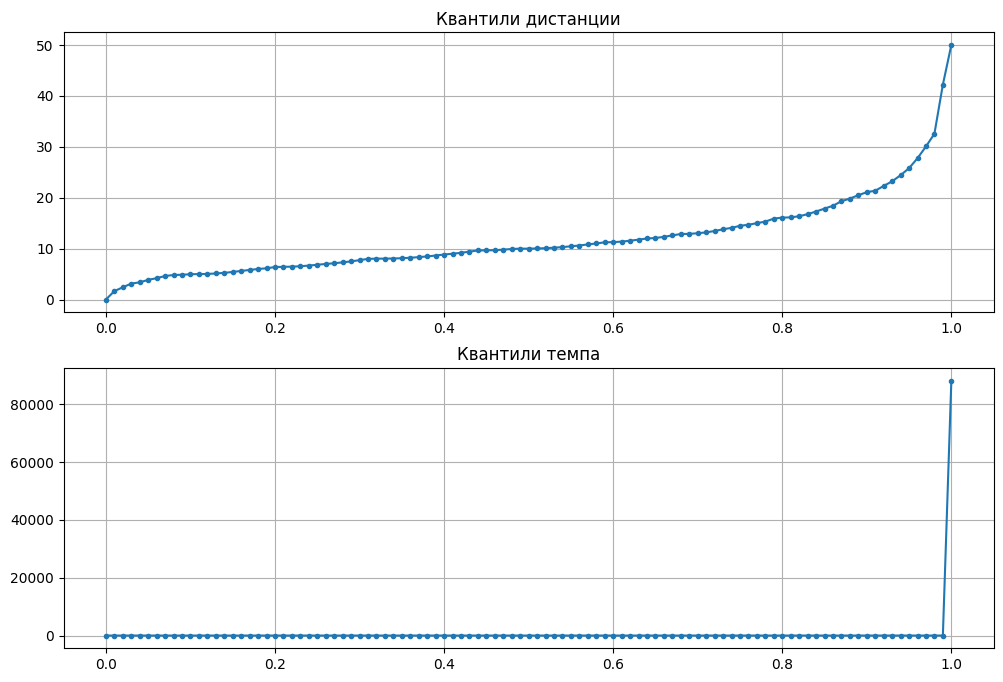

In [ ]:
def create_quantiles_distance_pace(count_quantiles):
    quantiles = [i * 1 / count_quantiles for i in range(count_quantiles + 1)]
    quantiles_distance = data["distance"].quantile(quantiles)
    quantiles_pace = data["pace"].quantile(quantiles)

    fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(12, 8))

    ax[0].plot(quantiles, quantiles_distance, marker='.')
    ax[0].set_title("Квантили дистанции")
    ax[0].grid()

    ax[1].plot(quantiles, quantiles_pace, marker='.')
    ax[1].set_title("Квантили темпа")
    ax[1].grid()
create_quantiles_distance_pace(100)

Вышеприведенные рассуждения говорят о том, что нужно обрезать по темпу

In [ ]:
print(f"Количество пробежек, с темпом > 15 мин/км: {(data['pace'] > 15).sum()}")
mask = data["pace"] > 15
data.drop(index=data.index[mask], inplace=True)

Количество пробежек, с темпом > 15 мин/км: 19422


Еще раз посмотрим на квантили: (теперь получше) на самом деле темп == 15 мин/км это очень мало, потому что для человека, который идет пешком темп в среднем 12 мин/км

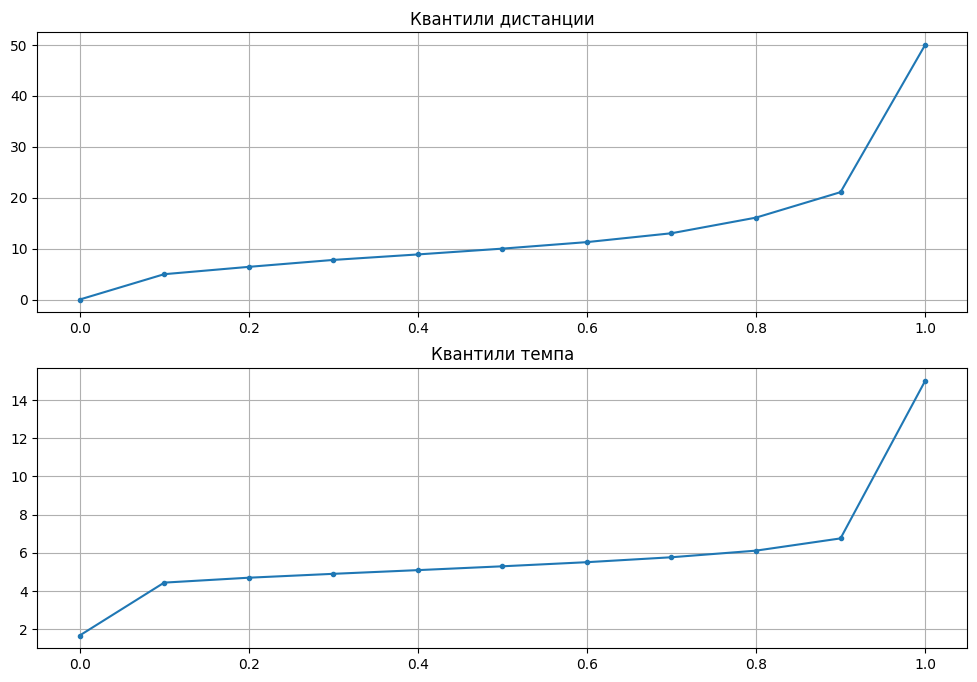

In [ ]:
create_quantiles_distance_pace(10)

Теперь, когда более-менее выровняли темп, то перейдем к рассмотрению "контингента" этого датасета

In [ ]:
print(f"Процент мужчин: {(data['gender'] == 'M').sum() / len(data) * 100:.2f}%")
print(f"Процент женщин: {(data['gender'] == 'F').sum() / len(data) * 100:.2f}%")

Процент мужчин: 76.00%
Процент женщин: 24.00%


In [ ]:
print("Страны, из которых были бегуны")
df_country = data.groupby("country").count().to_dict()["place"]
df_country = pd.DataFrame({"country": df_country.keys(), "count": df_country.values()})
fig = px.choropleth(df_country,
                    locations="country",
                    locationmode='country names',
                    color="count",
                    color_continuous_scale=['lightgray', 'green'])
fig.show()

Страны, из которых были бегуны


И посмотрим на возрастные категории

<Axes: xlabel='age_group', ylabel='Count'>

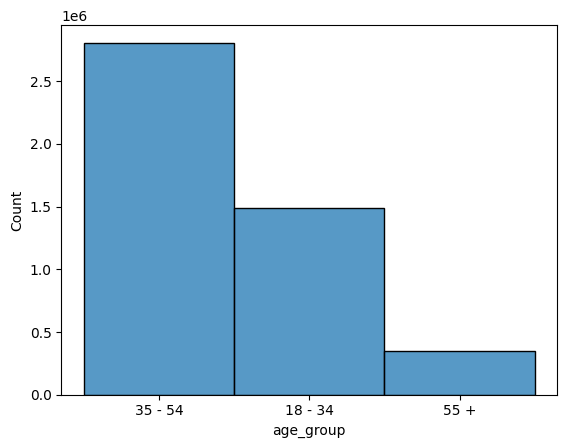

In [ ]:
sns.histplot(data=data, x="age_group")

In [ ]:
print(f"Общее количество бегунов: {len(data['athlete'].unique())}")

Общее количество бегунов: 36398


#Перейдем к визуализациям взаимосвязей между переменными

Так как таргет - темп, то посмотрим на то, что его определяет и корреляцию с другими фичами

График выглядит так, потому что мы обрезали темп

Также построим линейную регрессию, которая "выходит из нуля"

Видно, что остатки не нормальны (это видно и из графика ниже,э то вообще не удивительно), но остатки не автокоррелированы, это хорошее свойство модели.
$R^2$=0.955 - это означает, что эти две фичи хорошо коррелируют, что может плохо сказаться на предсказаниях линейной регрессии, если использовать обе эти фичи

In [ ]:
model = OLS(data["time_jog"], data["distance"])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:               time_jog   R-squared (uncentered):                   0.955
Model:                            OLS   Adj. R-squared (uncentered):              0.955
Method:                 Least Squares   F-statistic:                          9.942e+07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):                        0.00
Time:                        13:54:02   Log-Likelihood:                     -1.9508e+07
No. Observations:             4647424   AIC:                                  3.902e+07
Df Residuals:                 4647423   BIC:                                  3.902e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
distance       5.4043      0.001   9971.190      0.000       5.403       5.405
==============================================================================
Omnibus:                  4681030.270   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        663090222.478
Skew:                           4.671   Prob(JB):                         0.00
Kurtosis:                      60.767   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



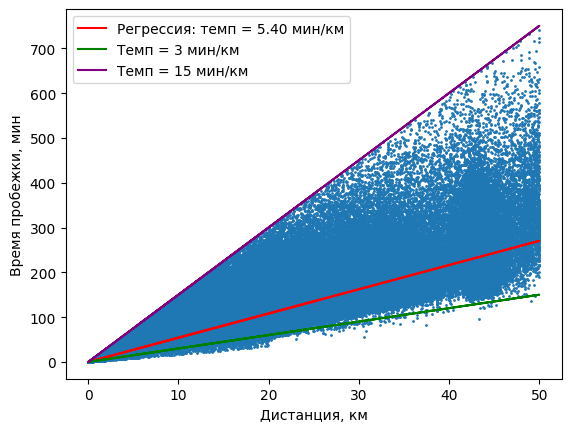

In [ ]:
a = result.params.iloc[0]
pace_min = 3
pace_max = 15

plt.scatter(data["distance"], data["time_jog"], s=1)
plt.plot(data["distance"], a * data["distance"], color="red", label=[f"Регрессия: темп = {float(a):.2f} мин/км"])
plt.plot(data["distance"], pace_min * data["distance"], color = "green", label=["Темп = 3 мин/км"])
plt.plot(data["distance"], pace_max * data["distance"], color="purple", label=["Темп = 15 мин/км"])
plt.xlabel("Дистанция, км")
plt.ylabel("Время пробежки, мин")
plt.legend()

Теперь посмотрим на корреляции числовых фич и таргета. Как видим, корреляция с целевой переменной крайне низкая, что говорит о том, что линейные модели будут справляться плохо

<Axes: >

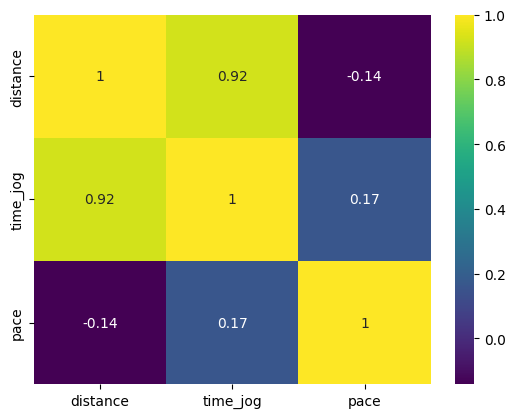

In [ ]:
sns.heatmap(data[["distance", "time_jog", "pace"]].corr(), cmap="viridis", annot=True)

Посмотрим на зависимости таргета от времени пробежки и дистанции

Text(0, 0.5, 'Темп, км/мин')

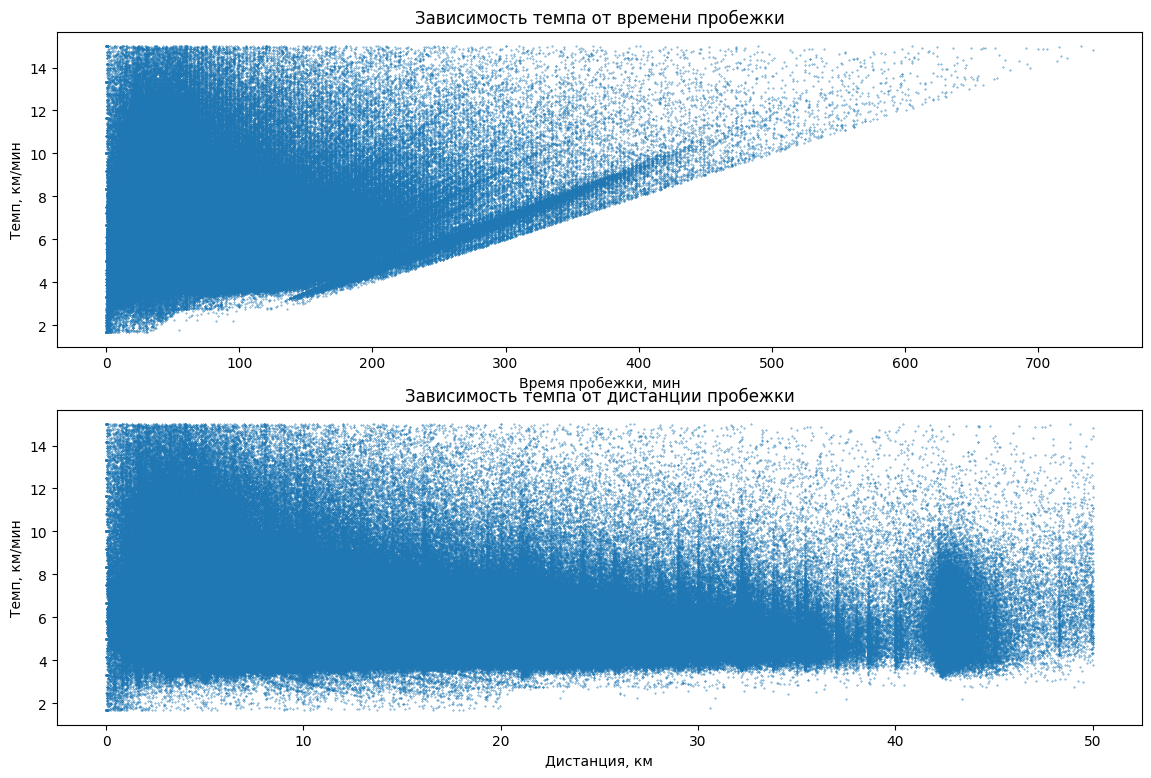

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(14, 9))

ax[0].scatter(data["time_jog"], data["pace"], s=0.1)
ax[0].set_title("Зависимость темпа от времени пробежки")
ax[0].set_xlabel("Время пробежки, мин")
ax[0].set_ylabel("Темп, км/мин")

ax[1].scatter(data["distance"], data["pace"], s=0.1)
ax[1].set_title("Зависимость темпа от дистанции пробежки")
ax[1].set_xlabel("Дистанция, км")
ax[1].set_ylabel("Темп, км/мин")

Посмотрим на распределение времени пробежки и дистанции

Как видно из гистаграммы для времени, слишком много ооочень длинных пробежек, что говорит о том, что это скорее всего выборосы, это проверим попозже

In [ ]:
def take_stats_and_hist(data, column, bins="auto"):
    print(f"Среднее: {data[column].mean():.2f}")
    print(f"Медиана: {data[column].median():.2f}")
    print(f"Стандартное отклонение от среднего: {data[column].std():.2f}")
    sns.histplot(data=data, x=column, bins=bins, stat="density")

Статистика по времени пробежки
Среднее: 63.72
Медиана: 53.97
Стандартное отклонение от среднего: 41.74


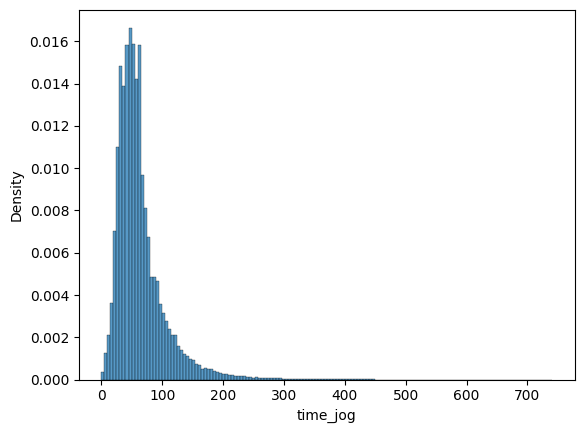

In [ ]:
print("Статистика по времени пробежки")
take_stats_and_hist(data, "time_jog", bins=150)

Статистика по дистанции пробежки
Среднее: 11.75
Медиана: 10.01
Стандартное отклонение от среднего: 7.19


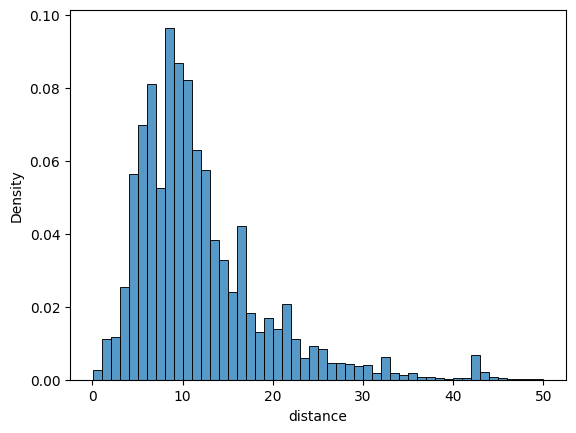

In [ ]:
print("Статистика по дистанции пробежки")
take_stats_and_hist(data, "distance", bins=50)

Так как бот будет работать на категорию СНГ (даже Россию, то посмотрим как соотносятся результаты бегунов из России с другими бегунами)
Немного странно, что в place какие-то там немецкие города, но ладно

Но если серьезно, то country — колонка, содержащая страну происхождения спортсмена, а place — место и дату марафона, который пробежал спортсмен

In [ ]:
data_russia = data[data["country"] == "Russia"]
data_russia.head()

,datetime,athlete,distance,time_jog,gender,age_group,country,place,pace
65,2019-01-01,69,2.34,13.266667,M,18 - 34,Russia,BERLIN 2019,5.669516
172,2019-01-01,182,8.00,39.150000,M,18 - 34,Russia,BERLIN 2019,4.893750
312,2019-01-01,327,10.00,54.533333,F,35 - 54,Russia,"BERLIN 2018,NEW YORK 2017",5.453333
422,2019-01-01,446,5.00,26.866667,M,35 - 54,Russia,BERLIN 2019,5.373333
455,2019-01-01,482,10.02,65.000000,F,35 - 54,Russia,BERLIN 2018,6.487026


In [ ]:
#Количество бегунов из России
count_russia_athlete = len(data_russia["athlete"].unique())
print(f"Количество бегунов из России: {count_russia_athlete}")
print(f"Процент бегунов от общего количества {count_russia_athlete / len(data['athlete'].unique()) * 100:.2f}%")

Количество бегунов из России: 333
Процент бегунов от общего количества 0.91%


Посмотрим на распределение целевой переменной и основных фич

Статистика по темпу
Среднее: 5.77
Медиана: 5.64
Стандартное отклонение от среднего: 1.07


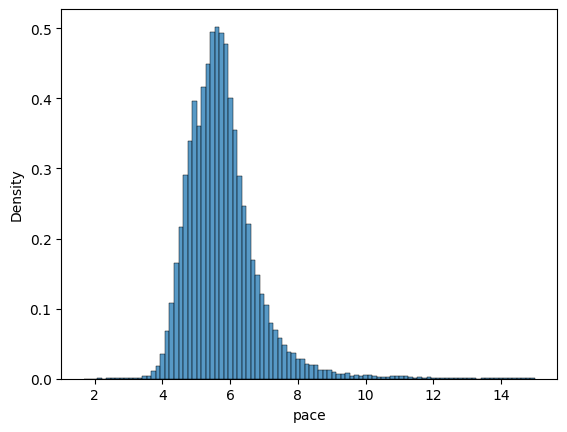

In [ ]:
print("Статистика по темпу")
take_stats_and_hist(data=data_russia, column="pace", bins=100)

Статистика по времени пробежки
Среднее: 68.30
Медиана: 60.00
Стандартное отклонение от среднего: 37.09


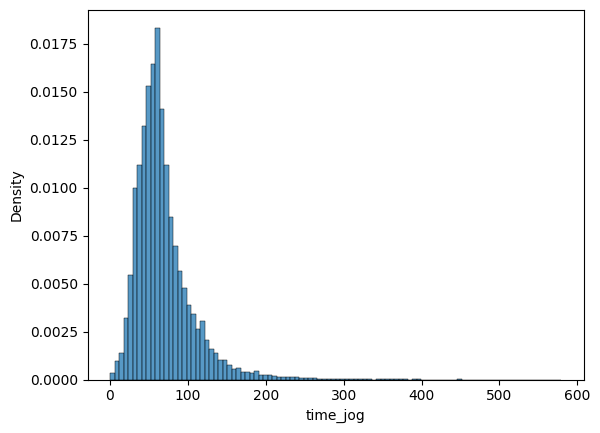

In [ ]:
print("Статистика по времени пробежки")
take_stats_and_hist(data_russia, "time_jog", bins=100)

Статистика по дистанции пробежки
Среднее: 12.16
Медиана: 10.44
Стандартное отклонение от среднего: 6.77


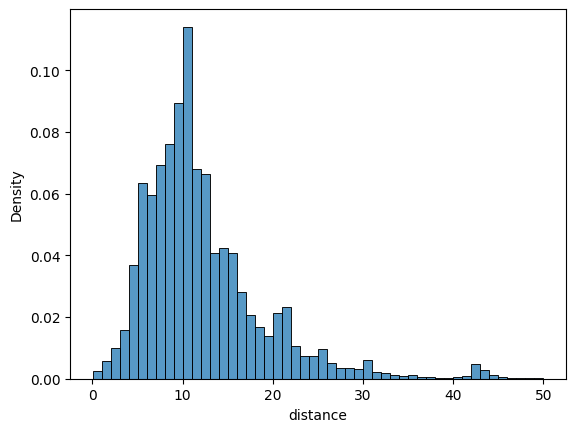

In [ ]:
print("Статистика по дистанции пробежки")
take_stats_and_hist(data=data_russia, column="distance", bins=50)

Как мы видим, в среднем время пробежки больше, а дистанция меньше

#Теперь займемся дополнительной чисткой данных

Посмотрим на очень долгие пробежки

In [ ]:
data_long = data[data["time_jog"] > 120] #Для сравнения для любителя это время как раз полумарафон
data_long.head()

,datetime,athlete,distance,time_jog,gender,age_group,country,place,pace
57,2019-01-01,61,30.70,159.000000,M,35 - 54,Switzerland,"BERLIN 2014,BERLIN 2017,BOSTON 2019",5.179153
78,2019-01-01,83,31.80,349.666667,M,35 - 54,United Kingdom,"BERLIN 2016,BERLIN 2017,BOSTON 2015",10.995807
122,2019-01-01,131,21.47,167.000000,M,35 - 54,United States,BOSTON 2019,7.778295
123,2019-01-01,132,20.40,125.000000,F,18 - 34,United States,"BERLIN 2017,BOSTON 2018,NEW YORK 2019",6.127451
131,2019-01-01,140,21.39,130.000000,M,55 +,Netherlands,NEW YORK 2019,6.077606


Как видим из гистограммы для темпа, из подозрительных участков можно проверить только участки большого темпа

<Axes: xlabel='pace', ylabel='Count'>

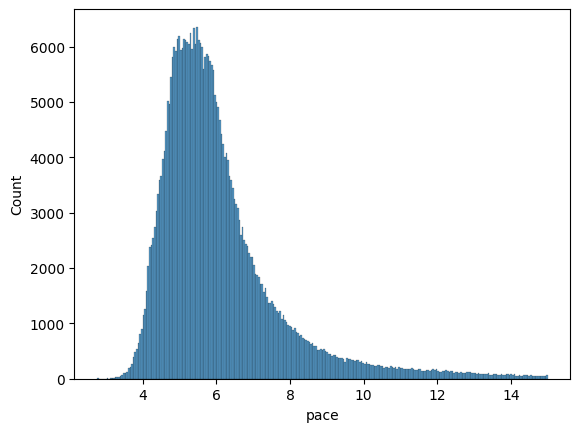

In [ ]:
sns.histplot(data=data_long, x="pace")

То есть есть пробежки длинной меньше 10 км (это не очень длинные пробежки, поэтому темп высоковатый, но пожалуй оставим)

<Axes: xlabel='distance', ylabel='Count'>

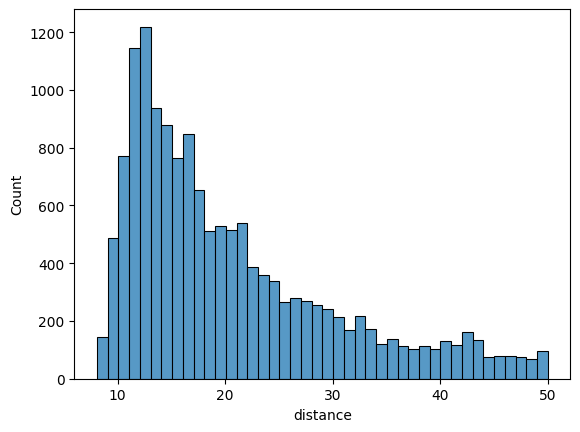

In [ ]:
sns.histplot(data=data_long[data_long["pace"]>10], x="distance")

Посмотрим на короткие дистанции

In [ ]:
data[data["distance"] < 1].head()

,datetime,athlete,distance,time_jog,gender,age_group,country,place,pace
114,2019-01-01,123,0.60,3.900000,F,18 - 34,United States,NEW YORK 2015,6.500000
1478,2019-01-01,1551,0.01,0.133333,F,35 - 54,United Kingdom,LONDON 2017,13.333333
4235,2019-01-01,4406,0.72,5.066667,M,35 - 54,Norway,NEW YORK 2017,7.037037
5795,2019-01-01,6019,0.80,5.916667,M,35 - 54,United States,BOSTON 2017,7.395833
6526,2019-01-01,6766,0.46,0.866667,M,35 - 54,Italy,"BOSTON 2019,LONDON 2018",1.884058


Для дистанций меньше 1 км темп больше 5 мин/км является крайне подозрительным, будем считать, что наш бот не рассчитан на такие пробежки, поэтому просто удалим их

In [ ]:
mask = (data["distance"] < 1) & (data["pace"] > 5)
print(f"Количество таких пробежек: {mask.sum()}")
data.drop(index=data.index[mask], inplace=True)

Количество таких пробежек: 9452


#Feature engineering

Так как потом на этих данных будут учиться модельки, то нужно добавить определенные фичи, которые помогут модели. Философия такая, что перед пробежкой пользователь задает либо желаемую дистанцию пробежки, либо ее желаемое время и бот в виде "соперника" говорит, что этот "соперник" пробежал с таким то темпом и твоя задача победить.

Это будут:

— темпы последних 10 пробежек

— последний темп за пробежку примерно с той же дистанцией (возьмем разность в 500 метров)

— последний темп за пробежку примерно с той же продолжительностью (возьмем разность в 3 минуты)

Тут используем то, что данные уже отсортированы по времени

Здесь получится много nan значений, но в процентах не так то уж и много, поэтому просто их удалим

In [ ]:
def add_near_jog(data, type_feature="distance", delta=0.5):
    """
    type_feature - distance | time_jog
    """
    #Тут я ничего лучше не придумал
    athlets = data['athlete'].unique()
    data[f"last_{type_feature}_pace"] = np.nan
    for athlete in athlets:
        data_athlete = data[data["athlete"] == athlete][[type_feature, "pace"]]
        arr_pace_athlete = np.full(len(data_athlete), np.nan)
        for i in range(len(data_athlete)):
            for j in range(i - 1, -1, -1):
                if (data_athlete[type_feature].iloc[j] < data_athlete[type_feature].iloc[i] + delta and
                data_athlete[type_feature].iloc[j] > data_athlete[type_feature].iloc[i] - delta):
                    arr_pace_athlete[i] = data_athlete["pace"].iloc[j]
                    break
        data.loc[data["athlete"] == athlete, f"last_{type_feature}_pace"] = arr_pace_athlete

In [ ]:
p = 10

for i in range(p):
    data[f"pace_lag_{i + 1}"] = data.groupby("athlete")["pace"].shift(i + 1)
print(f"Количество nan строк: {data.isna().sum()['pace_lag_10'] / len(data):.4f}%")
data.dropna(inplace=True)

#Можно было бы обьединить, но я не стал
add_near_jog(data, type_feature="distance", delta=0.5)
add_near_jog(data, type_feature="time_jog", delta=3)

print(f"Количество nan строк: {data.isna().sum()['last_distance_pace'] / len(data):.4f}%")
print(f"Количество nan строк: {data.isna().sum()['last_time_jog_pace'] / len(data):.4f}%")
data.dropna(inplace=True)
data.head()

Количество nan строк: 0.0000%
Количество nan строк: 0.1677%
Количество nan строк: 0.1745%


,datetime,athlete,distance,time_jog,gender,age_group,country,place,pace,pace_lag_1,...,pace_lag_3,pace_lag_4,pace_lag_5,pace_lag_6,pace_lag_7,pace_lag_8,pace_lag_9,pace_lag_10,last_distance_pace,last_time_jog_pace
400648,2019-01-12,125,13.28,61.000000,F,18 - 34,United States,"BERLIN 2019,BOSTON 2016",4.593373,4.594181,...,4.885227,5.070132,5.152717,4.805915,4.419431,5.131678,4.690619,4.732351,4.594181,4.594181
400766,2019-01-12,247,5.90,30.133333,M,35 - 54,Canada,CHICAGO 2019,5.107345,5.678679,...,5.878004,5.960286,5.281690,5.468750,5.780952,6.131276,5.040266,5.711538,5.678679,5.678679
401420,2019-01-12,931,1.68,10.133333,M,35 - 54,United States,NEW YORK 2014,6.031746,5.670732,...,5.047348,5.708583,6.876248,7.765766,4.798517,6.423611,6.178161,5.664683,5.670732,5.670732
401920,2019-01-12,1454,11.10,52.433333,M,35 - 54,United Kingdom,LONDON 2019,4.723724,5.129991,...,4.622871,4.565928,4.429612,4.449810,4.722395,4.341801,4.216880,4.323995,5.129991,5.129991
402148,2019-01-12,1700,5.04,21.933333,M,18 - 34,United Kingdom,LONDON 2018,4.351852,4.750000,...,5.964646,4.797222,5.220441,5.274043,4.000000,4.693333,4.542593,4.824841,4.750000,4.750000


In [ ]:
data[data["athlete"] == 37594]

,datetime,athlete,distance,time_jog,gender,age_group,country,place,pace,pace_lag_1,...,pace_lag_3,pace_lag_4,pace_lag_5,pace_lag_6,pace_lag_7,pace_lag_8,pace_lag_9,pace_lag_10,last_distance_pace,last_time_jog_pace
801059,2019-01-22,37594,20.000,101.150000,M,18 - 34,United Kingdom,BERLIN 2017,5.057500,4.919808,...,4.848399,4.533672,5.094927,4.545455,4.933775,3.695652,4.523702,4.857143,4.919808,4.919808
910295,2019-01-25,37594,21.180,101.166667,M,18 - 34,United Kingdom,BERLIN 2017,4.776519,4.482072,...,5.057500,4.919808,3.977496,4.848399,4.533672,5.094927,4.545455,4.933775,5.094927,5.057500
946707,2019-01-26,37594,25.949,114.300000,M,18 - 34,United Kingdom,BERLIN 2017,4.404794,4.776519,...,4.901749,5.057500,4.919808,3.977496,4.848399,4.533672,5.094927,4.545455,4.533672,4.533672
1019531,2019-01-28,37594,17.510,86.816667,M,18 - 34,United Kingdom,BERLIN 2017,4.958119,3.658958,...,4.776519,4.482072,4.901749,5.057500,4.919808,3.977496,4.848399,4.533672,4.848399,4.848399
1092355,2019-01-30,37594,20.000,87.000000,M,18 - 34,United Kingdom,BERLIN 2017,4.350000,5.142915,...,3.658958,4.404794,4.776519,4.482072,4.901749,5.057500,4.919808,3.977496,4.482072,4.958119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12999079,2019-12-23,37594,5.060,24.333333,M,18 - 34,United Kingdom,BERLIN 2017,4.808959,4.582660,...,4.604758,4.406942,4.664189,4.902326,4.480100,4.717425,4.028609,4.690104,4.028609,5.028958
13035491,2019-12-24,37594,2.360,11.916667,M,18 - 34,United Kingdom,BERLIN 2017,5.049435,4.808959,...,9.575254,4.604758,4.406942,4.664189,4.902326,4.480100,4.717425,4.028609,4.651325,4.651325
13181139,2019-12-28,37594,3.900,19.000000,M,18 - 34,United Kingdom,BERLIN 2017,4.871795,5.049435,...,4.582660,9.575254,4.604758,4.406942,4.664189,4.902326,4.480100,4.717425,9.575254,4.028609
13253963,2019-12-30,37594,4.019,19.550000,M,18 - 34,United Kingdom,BERLIN 2017,4.864394,4.871795,...,4.808959,4.582660,9.575254,4.604758,4.406942,4.664189,4.902326,4.480100,4.871795,4.871795


Посмотрим на корреляцию признаков

<Axes: >

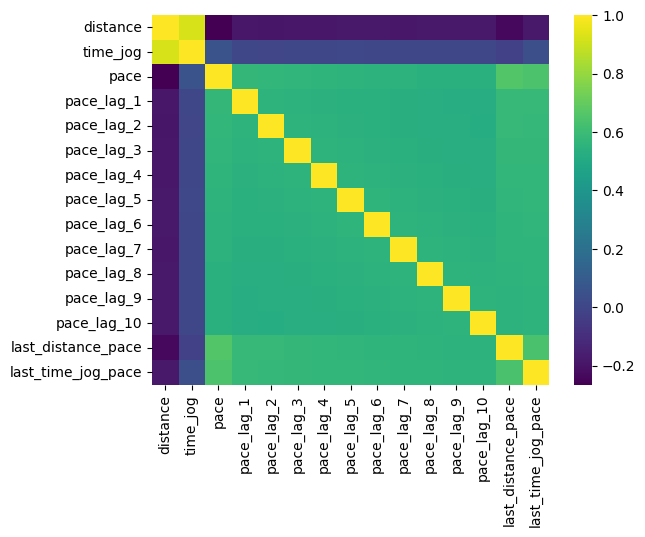

In [ ]:
sns.heatmap(data.drop(columns=["datetime", "athlete", "gender", "age_group", "country", "place"]).corr(), cmap="viridis")

Как видим, все лаги темпа достаточно сильно коррелируют, что не очень хорошо будет для линейных моделей, например линейной регрессии, но это не страшно

#Сохранение данных

In [ ]:
data.to_csv("", index=False)